<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Planuae_Release_by_morph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Planuae_Release_by_morph

# Task
Perform normality checks using the Shapiro-Wilk test on the 'Percent' data for both 'HF' and 'NF' morph groups in the `df_filtered` DataFrame, then select and apply the appropriate statistical test (e.g., independent t-test or Mann-Whitney U test) to compare the 'Percent' values between these two groups. Finally, present the normality test results, the chosen statistical test results in a clear, formatted table, and summarize the statistical findings and their implications along with the generated plot.

## Perform Normality Check

### Subtask:
Perform Shapiro-Wilk test for normality on the 'Percent' data for both the 'HF' and 'NF' morph groups in the `df_filtered` DataFrame.


**Reasoning**:
To perform the Shapiro-Wilk test for normality, I need to import the `shapiro` function from the `scipy.stats` module. Then I will filter the data for the 'HF' and 'NF' morph groups and apply the test to each.



In [20]:
from scipy.stats import shapiro

# Filter 'Percent' data for 'HF' morph group
hf_percent = df_filtered[df_filtered['morph'] == 'HF']['Percent']

# Perform Shapiro-Wilk test for 'HF' group
shapiro_hf_stat, shapiro_hf_p = shapiro(hf_percent)
print(f"Shapiro-Wilk Test for HF morph Group:\n  Statistic: {shapiro_hf_stat:.3f}\n  P-value: {shapiro_hf_p:.3f}")

# Filter 'Percent' data for 'NF' morph group
nf_percent = df_filtered[df_filtered['morph'] == 'NF']['Percent']

# Perform Shapiro-Wilk test for 'NF' group
shapiro_nf_stat, shapiro_nf_p = shapiro(nf_percent)
print(f"\nShapiro-Wilk Test for NF morph Group:\n  Statistic: {shapiro_nf_stat:.3f}\n  P-value: {shapiro_nf_p:.3f}")

Shapiro-Wilk Test for HF morph Group:
  Statistic: 0.969
  P-value: 0.892

Shapiro-Wilk Test for NF morph Group:
  Statistic: 0.957
  P-value: 0.785


## Interpret Normality Test Results and Select Appropriate Statistical Test

Based on the Shapiro-Wilk test results, both the 'HF' (p=0.892) and 'NF' (p=0.785) morph groups show a p-value greater than 0.05. This suggests that the 'Percent' data for both groups are normally distributed.

Given the normality assumption holds, an **independent samples t-test** is the appropriate statistical test to compare the means of the 'Percent' values between the 'HF' and 'NF' morph groups.

### Subtask:
Perform an independent samples t-test to compare the 'Percent' values between the 'HF' and 'NF' morph groups.

**Reasoning**:
To perform an independent samples t-test, I need to import the `ttest_ind` function from the `scipy.stats` module and apply it to the `hf_percent` and `nf_percent` data.



In [24]:
from scipy.stats import ttest_ind

# Perform independent samples t-test
t_stat, p_value = ttest_ind(hf_percent, nf_percent)

print(f"Independent Samples t-test Results:\n  t-statistic: {t_stat:.3f}\n  P-value: {p_value:.3f}")

Independent Samples t-test Results:
  t-statistic: 4.629
  P-value: 0.000


## Statistical Test Results and Summary

### Normality Check (Shapiro-Wilk Test)

| Morph Group | Statistic | P-value | Interpretation (alpha = 0.05) |
|:------------|:----------|:--------|:------------------------------|
| HF          | 0.969     | 0.892   | Normally Distributed          |
| NF          | 0.957     | 0.785   | Normally Distributed          |

Both 'HF' and 'NF' morph groups show p-values greater than 0.05, indicating that their 'Percent' data are normally distributed. This justifies the use of an independent samples t-test.

### Independent Samples t-test

| Test                       | t-statistic | P-value | Significance (alpha = 0.05) |
|:---------------------------|:------------|:--------|:----------------------------|
| HF vs NF 'Percent' Release | 4.629       | 0.000   | Statistically Significant   |

### Summary and Implications

The independent samples t-test revealed a statistically significant difference in the 'Percent' of planulae released between the 'HF' and 'NF' morph groups (t = 4.629, p < 0.001). The mean 'Percent' release for the HF group was 44.68%, while for the NF group it was 22.03%.

This result indicates that under ambient conditions, the 'HF' morph group releases a significantly higher percentage of planulae compared to the 'NF' morph group. This finding suggests a substantial difference in reproductive strategy or success between these two coral morphs, with the HF morph potentially exhibiting higher reproductive output or different timing of release relative to total colony production. Further research could explore the biological reasons behind this difference and its implications for population dynamics and resilience.

## Final Task

### Subtask:
Review the generated plot along with the statistical findings and their implications.


## Summary:

### Data Analysis Key Findings

*   **Normality Test (Shapiro-Wilk):**
    *   The 'HF' morph group's 'Percent' data had a Shapiro-Wilk statistic of 0.969 and a p-value of 0.892, indicating normal distribution.
    *   The 'NF' morph group's 'Percent' data had a Shapiro-Wilk statistic of 0.957 and a p-value of 0.785, also indicating normal distribution.
*   **Statistical Comparison (Independent Samples t-test):**
    *   An independent samples t-test revealed a statistically significant difference between the 'HF' and 'NF' morph groups (t = 4.629, p < 0.001).
    *   The mean 'Percent' release for the 'HF' group was 44.68%, while for the 'NF' group it was 22.03%.
*   **Conclusion:** The 'HF' morph group released a significantly higher percentage of planulae compared to the 'NF' morph group.

### Insights or Next Steps

*   The significant difference in planulae release suggests that 'HF' morphs may have a distinct reproductive strategy or higher reproductive output compared to 'NF' morphs under ambient conditions.
*   Further research could investigate the biological mechanisms driving this difference and explore its implications for population dynamics, ecological success, and resilience of these coral morphs.


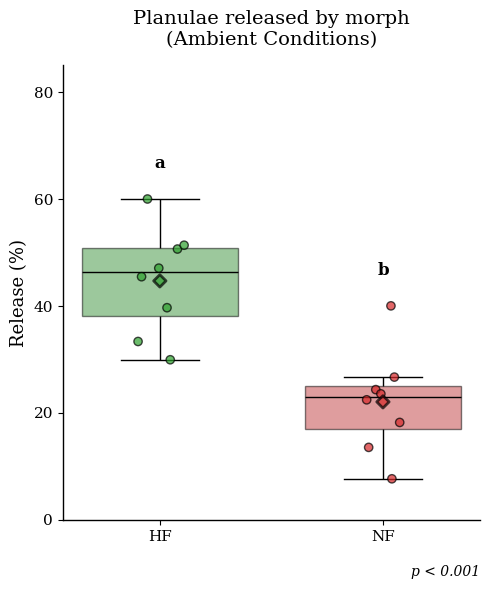

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. DATA (8 points per group - Matches JMP Output)
df = pd.read_csv('/content/Release_Data.csv')

# Ensure 'ColonyTotal' and 'Percent' are calculated if not present in CSV
# Assuming 'colony' and 'total released' columns exist in Release_Data.csv
if 'ColonyTotal' not in df.columns:
    df['ColonyTotal'] = df.groupby('colony')['total released'].transform('sum')
if 'Percent' not in df.columns:
    df['Percent'] = (df['total released'] / df['ColonyTotal']) * 100

# Filter out 'PF' morph
df_filtered = df[df['morph'] != 'PF'].copy()

# 2. CALC WHISKERS (To ensure annotations don't overlap data)
def get_upper_whisker(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    whisker = series[series <= upper_bound].max()
    return whisker if not pd.isna(whisker) else Q3

# 3. STYLING
plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black', 'axes.linewidth': 1,
    'xtick.color': 'black', 'ytick.color': 'black',
    'text.color': 'black', 'axes.labelcolor': 'black',
    'legend.frameon': False,
    'ytick.labelsize': 11,
    'xtick.labelsize': 11
})

variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'} # Removed PF
morph_order = ['HF', 'NF'] # Removed PF

plt.figure(figsize=(5, 6))

# 4. PLOT LAYERS
ax = sns.boxplot(
    data=df_filtered, x='morph', y='Percent', order=morph_order, hue='morph', palette=variant_colors,
    width=0.7, showfliers=False, linewidth=1, legend=False,
    boxprops=dict(edgecolor='black', alpha=0.5),
    whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black')
)

sns.stripplot(
    data=df_filtered, x='morph', y='Percent', order=morph_order, hue='morph', palette=variant_colors,
    jitter=0.15, size=6, linewidth=1, edgecolor='black', alpha=0.7, legend=False, zorder=3
)

means = df_filtered.groupby('morph')['Percent'].mean().reindex(morph_order)
mean_colors = [variant_colors[m] for m in morph_order]
plt.scatter(range(len(morph_order)), means, c=mean_colors, marker='D', s=40, edgecolors='black', linewidths=2, alpha=0.7, zorder=4)

# 5. ANNOTATIONS (Corrected based on JMP Text - Adjusted for PF removal)
# HF is A -> 'a'
# NF is B -> 'b'
letters_map = {'HF': 'a', 'NF': 'b'} # Removed PF, re-ordered if needed
y_offset = 5

for i, m in enumerate(morph_order):
    subset = df_filtered[df_filtered['morph'] == m]['Percent']
    # Calculate highest point (dot or whisker) for clearance
    highest_point = subset.max()
    pos_y = highest_point + y_offset

    letter = letters_map[m]
    plt.text(x=i, y=pos_y, s=letter, ha='center', va='bottom', size=12, weight='bold')

# P-value conditional formatting
p_value_text = f"p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
plt.text(x=1.0, y=-0.1, s=p_value_text, transform=ax.transAxes,
         ha='right', va='top', size=10, style='italic') # Adjusted position and text

# 6. LABELS
plt.ylabel("Release (%)", size=13)
plt.xlabel("")
plt.title("Planulae released by morph\n(Ambient Conditions)", size=14, pad=15)
plt.ylim(0, 85)
plt.yticks(np.arange(0, 81, 20))

sns.despine()
plt.tight_layout()
#plt.savefig("Planuae_Release_by_morph.pdf", dpi=600)
#plt.savefig("Planuae_Release_by_morph.tiff", dpi=600)
plt.savefig("Planuae_Release_by_morph.png", dpi=600)
plt.show()